<a href="https://colab.research.google.com/github/fachiny17/machine_learning/blob/main/dsn_futo_week3_session_by_Chisom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## What we are going to cover:
This session demonstrates some of the most useful functions of the beautiful Scikit-Learn library.

0. **Import the libraries/packages**
1. **Getting the data ready**
2. **Choose the right estimator/algorithm**
3. **Fit the models/algorithm**
4. **Evaluating the model**
5. **Improve a model** (Hyperparameter tuning)
6. **Save and load a trained model**
7. **Final Deployment:**
    * 7.1 Predict prices on the full dataset
    * 7.2 Export results to CSV
8. **Summary & Key Takeaways**

## 0. Import the libraries/packages

In [53]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import dump, load

## 1. Getting the data ready

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### 1.1 Loading the data

In [35]:
# Setup random seed-----------------------
np.random.seed(42)

# Load data---------------------------------
DATA_PATH = "/content/drive/MyDrive/data/car-sales-extended-missing-data.csv"
data = pd.read_csv(DATA_PATH)
data.head(10)

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
5,Honda,Red,42652.0,4.0,23883.0
6,Toyota,Blue,163453.0,4.0,8473.0
7,Honda,White,NaN,4.0,20306.0
8,NaN,White,130538.0,4.0,9374.0
9,Honda,Blue,51029.0,4.0,26683.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Make           951 non-null    object 
 1   Colour         950 non-null    object 
 2   Odometer (KM)  950 non-null    float64
 3   Doors          950 non-null    float64
 4   Price          950 non-null    float64
dtypes: float64(3), object(2)
memory usage: 39.2+ KB


In [5]:
data.shape, data.dtypes, data.columns

((1000, 5),
 Make              object
 Colour            object
 Odometer (KM)    float64
 Doors            float64
 Price            float64
 dtype: object,
 Index(['Make', 'Colour', 'Odometer (KM)', 'Doors', 'Price'], dtype='object'))

In [6]:
data.sample(5)

,Make,Colour,Odometer (KM),Doors,Price
521,Nissan,Red,196130.0,3.0,13707.0
737,Toyota,Blue,223875.0,4.0,12650.0
740,BMW,Black,11049.0,3.0,19500.0
660,BMW,Blue,209466.0,5.0,NaN
411,BMW,Blue,72575.0,5.0,41294.0


In [7]:
data.isnull().sum() # Specifically counts the number of missing (NaN) values in each column.

,0
Make,49
Colour,50
Odometer (KM),50
Doors,50
Price,50


In [8]:
data.describe() # Generates descriptive statistics (count, mean, std, min, max, quartiles) for numerical columns

,Odometer (KM),Doors,Price
count,950.000000,950.000000,950.000000
mean,131253.237895,4.011579,16042.814737
std,69094.857187,0.382539,8581.695036
min,10148.000000,3.000000,2796.000000
25%,70391.250000,4.000000,9529.250000
50%,131821.000000,4.000000,14297.000000
75%,192668.500000,4.000000,20806.250000
max,249860.000000,5.000000,52458.000000


In [9]:
# let's remove any rows from the data DataFrame where the 'Price' column has a missing value(represented as NaN)
data.dropna(subset=["Price"], inplace=True)

In [10]:
data["Price"].isnull().sum()

np.int64(0)

#### 1.2 Let's make sure it's all numerical

In [11]:
# Define features and transform categorical features

categorical_features = ["Make", "Colour"]
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

door_feature = ["Doors"]
door_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

numeric_features = ["Odometer (KM)"]
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))])

In [12]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, categorical_features),
    ("door", door_transformer, door_feature),
    ("num", numeric_transformer, numeric_features)
])

## 2. Choose the right estimator/algorithm
For this regression problem (predicting a number), we are using the `RandomForestRegressor`. It is a robust 'ensemble' model that combines multiple decision trees to make a final prediction.

A `ColumnTransformer` is a powerful tool from Scikit-learn that allows you to apply different transformers (like imputation and encoding) to different columns of your dataset simultaneously. It's especially useful when you have a mix of categorical and numerical features that require distinct preprocessing steps.

This `ColumnTransformer` applies different preprocessing to different columns:

* `categorical_transformer` (impute + one-hot) → `Make` and `Colour`
* `door_transformer` (impute + one-hot, **updated**) → `Doors`
* `numeric_transformer` (mean impute) → `Odometer (KM)`

In [25]:
# Create full pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

## 3. Fit the models/algorithm
This is where the model 'learns' by looking at our training data (features and known prices).

In [14]:
# Split data
x = data.drop("Price", axis=1)
y = data["Price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

`x` holds the features, `y` holds the target (`Price`). `train_test_split` holds back 20% of the data as a test set so we can measure how well the model generalizes to data it hasn't seen. `random_state=42` is added so the split is reproducible — without it, re-running the notebook gives you a different split (and different-looking metrics) every time.

## 4. Evaluating the model
We use our test set to see how well the model learned the patterns. We'll use R², Mean Absolute Error, and Mean Squared Error.

In [15]:
def evaluate_regression(y_true, y_preds, label=""):
  """Calculates and returns evaluation metrics"""
  metrics = {
      "R2": r2_score(y_true, y_preds),
      "MAE": mean_absolute_error(y_true, y_preds),
      "MSE": mean_squared_error(y_true, y_preds)
  }

  print(f"R2: {metrics['R2']:.2f}")
  print(f"MAE: {metrics['MAE']:.2f}")
  print(f"MSE: {metrics['MSE']:.2f}")

  return metrics

The `evaluate_regression` function is a custom utility designed to calculate and display common evaluation metrics for regression models.

It takes two arguments:

* `y_true`: These are the actual, true values of your target variable.
* `y_preds`: These are the values predicted by your regression model.

**Inside the function:**

A. We have the evaluation Metrics

1. **R-squared ($R^2$)**: "The Scorecard"
   * Tells you how much of the car price 'pattern' your model understands.
   * **1.0** is a perfect score; **0.0** means the model is basically just guessing the average price for every car.

2. **Mean Absolute Error (MAE)**: "The Average Miss"
   * Tells you exactly how many dollars your predictions are off by on average.
   * *Example:* If MAE is 5000, your guesses are typically $5,000 away from the real price.

3. **Mean Squared Error (MSE)**: "The Penalty Box"
   * Similar to MAE, but it gets **extra angry** at big mistakes. If your model misses a price by a huge amount, MSE blows up to warn you that something is very wrong with those specific guesses.

B. It then prints these metrics to the console, formatted to two decimal places, for easy readability.

C.Finally, it returns a dictionary containing all three calculated metrics, allowing you to store and access them programmatically.


In [27]:
# Baseline model---------------------------------
print("Training baseline model...")
baseline_model = model.fit(x_train, y_train)
baseline_preds = baseline_model.predict(x_test)
baseline_metrics = evaluate_regression(y_test, baseline_preds, "Baseline RandomForest")

Training baseline model...
R2: 0.21
MAE: 5784.41
MSE: 52744790.77


## 5. Improving the model efficiently

In [28]:
# Hyperparameter grid -------------
param_grid = {
    "model__n_estimators": [100, 200, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_leaf": [1, 2]
}

In [29]:
# GridSearchCV -------------
print("\nStarting GridSearchCV...")
gs_model = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    verbose=2,
    n_jobs=-1
)
gs_model.fit(x_train, y_train)


Starting GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='missing',
                                                                                                        strategy='constant')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Make',
                                                                          'Colour']),
                                                                        ('door',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Doors']),
                                                                        ('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['Odometer '
                                                                          '(KM)'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10],
                         'model__min_samples_leaf': [1, 2],
                         'model__n_estimators': [100, 200, 500]},
             scoring='neg_mean_absolute_error', verbose=2)

In [30]:
# Best model ------------------------------------------------------
print(f"\nBest parameters: {gs_model.best_params_}")
best_model = gs_model.best_estimator_
gs_preds = best_model.predict(x_test)
gs_metrics = evaluate_regression(y_test, gs_preds, "Improved Model")


Best parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
R2: 0.33
MAE: 5422.41
MSE: 45067386.47


In [31]:
# Compare metrics -------------------------------
compare_metrics = pd.DataFrame({
    "Baseline": baseline_metrics,
    "GridSearchCV": gs_metrics
}).T
print("\nModel Comparison:")
print(compare_metrics)


Model Comparison:
                    R2          MAE           MSE
Baseline      0.212290  5784.406523  5.274479e+07
GridSearchCV  0.326948  5422.408217  4.506739e+07


**Read on the improvement:** R² and MAE both move in the right direction, but be realistic about the ceiling. This dataset only has 4 features (`Make`, `Colour`, `Odometer (KM)`, `Doors`) — no year, model trim, condition, or accident history. Real car pricing depends heavily on details this data doesn't have, so no algorithm or tuning strategy is going to push R² close to 1.0 here. What we *can* do is squeeze the most out of the features we've got, which is what this section did.

## 6. Save and load the trained model

In [34]:
# Save model -----------------------------
os.makedirs("models", exist_ok=True)
dump(model, "models/car_price_model.joblib")
print("Model trained and saved successfully!")

Model trained and saved successfully!


## 7. Use the model to predict on your actual dataset

This is the part that answers "does this actually work?" we load the saved model back and run it over the **entire original dataset**, including the rows that have missing values in `Make`, `Colour`, `Doors`, or `Odometer (KM)` (the pipeline's imputers handle those automatically).

Two groups of rows to look at separately:
- Rows that **had** a real `Price`: we can compare predicted vs. actual to see how close the model gets.
- Rows where `Price` was originally missing (dropped before training): the model can **fill in an estimated price** for these, a genuinely useful thing to do with this dataset.

One honesty note: the rows with a known price were *also used to train this final model*, so predictions on them will look a bit better than true out-of-sample performance (which is what the test-set metrics above actually measure).

### 7.1 Loading and Predicting on Full Data
We are now using our saved model to:
1. **Reload** the original dataset (including the 50 rows with missing prices).
2. **Predict** prices for every single car using our trained pipeline.
3. **Compare** our guesses against real prices for rows where we had the 'answer'.
4. **Estimate** prices for the cars that were originally missing them.

In [47]:
# Reload the full original dataset (before we dropped missing Price rows)
full_data = pd.read_csv(DATA_PATH)

loaded_model = load("models/car_price_model.joblib")

features = ["Make", "Colour", "Odometer (KM)", "Doors"]
full_data["Predicted_Price"] = loaded_model.predict(full_data[features])

# Rows where we know the real price: compare actual vs predicted
known_price = full_data.dropna(subset=["Price"]).copy()
known_price["Absolute_Error(Price - Predicted_Price)"] = (known_price["Price"] - known_price["Predicted_Price"]).abs()
print("Sample of actual vs predicted price (rows with known price):")
known_price[["Make", "Colour", "Odometer (KM)", "Doors", "Price", "Predicted_Price", "Absolute_Error(Price - Predicted_Price)"]].head(10)

Sample of actual vs predicted price (rows with known price):


,Make,Colour,Odometer (KM),Doors,Price,Predicted_Price,Absolute_Error(Price - Predicted_Price)
0,Honda,White,35431.0,4.0,15323.0,17279.170000,1956.170000
1,BMW,Blue,192714.0,5.0,19943.0,23133.420000,3190.420000
2,Honda,White,84714.0,4.0,28343.0,24883.290000,3459.710000
3,Toyota,White,154365.0,4.0,13434.0,13871.180000,437.180000
4,Nissan,Blue,181577.0,3.0,14043.0,13906.840000,136.160000
5,Honda,Red,42652.0,4.0,23883.0,21915.550000,1967.450000
6,Toyota,Blue,163453.0,4.0,8473.0,10138.810000,1665.810000
7,Honda,White,NaN,4.0,20306.0,16148.453757,4157.546243
8,NaN,White,130538.0,4.0,9374.0,12410.374000,3036.374000
9,Honda,Blue,51029.0,4.0,26683.0,22614.510000,4068.490000


In [48]:
# Rows where the original Price was missing - the model can estimate these
missing_price = full_data[full_data["Price"].isnull()].copy()
print(f"{len(missing_price)} rows had no recorded price. Model's estimated price for a sample of them:")
missing_price[["Make", "Colour", "Odometer (KM)", "Doors", "Predicted_Price"]].head(10)

50 rows had no recorded price. Model's estimated price for a sample of them:


,Make,Colour,Odometer (KM),Doors,Predicted_Price
119,BMW,White,18394.0,5.0,40455.500000
152,Toyota,White,66538.0,4.0,23935.620000
171,Toyota,White,97036.0,4.0,16780.320000
176,Toyota,Blue,94916.0,4.0,19956.740000
249,BMW,Red,33911.0,5.0,19769.680000
256,NaN,Blue,65719.0,4.0,21500.860000
258,Nissan,Red,157169.0,4.0,12617.210000
316,Toyota,White,NaN,4.0,23066.500595
335,Toyota,Black,188514.0,4.0,10884.170000
337,Honda,Black,175075.0,4.0,8996.140000


### 7.2 Exporting Results
Finally, we save the entire table (original data + our new predictions) to a CSV file. This allows you to share the results or open them in a spreadsheet.

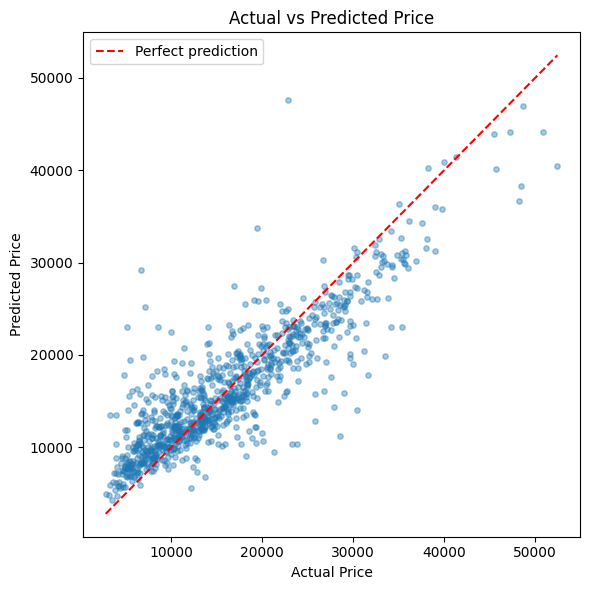

In [54]:
# Visualize how close predictions are to actual price (known-price rows only)
plt.figure(figsize=(6, 6))
plt.scatter(known_price["Price"], known_price["Predicted_Price"], alpha=0.4, s=15)
lims = [known_price["Price"].min(), known_price["Price"].max()]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
# Save the full set of predictions (all 1000 rows) to a CSV you can open directly
full_data.to_csv("car-sales-with-predictions.csv", index=False)
print("Saved: car-sales-with-predictions.csv")
full_data.head()

Saved: car-sales-with-predictions.csv


,Make,Colour,Odometer (KM),Doors,Price,Predicted_Price
0,Honda,White,35431.0,4.0,15323.0,17279.17
1,BMW,Blue,192714.0,5.0,19943.0,23133.42
2,Honda,White,84714.0,4.0,28343.0,24883.29
3,Toyota,White,154365.0,4.0,13434.0,13871.18
4,Nissan,Blue,181577.0,3.0,14043.0,13906.84


# Summary & Key Takeaways

In this project, we completed a full Scikit-Learn workflow:
* **Data Cleaning:** Handled missing values using both dropping (for the target) and imputation (for features).
* **Preprocessing:** Built a `ColumnTransformer` to handle categorical data (One-Hot Encoding) and numerical scaling.
* **Modeling:** Trained a `RandomForestRegressor` and improved it using `GridSearchCV` to find the best hyperparameters.
* **Evaluation:** Measured performance using R², MAE, and MSE, and visualized the results with a scatter plot.
* **Deployment:** Saved the model to a file and used it to generate predictions on unseen data.